# Notebook 06 — Classification EDA

**Project:** SciSpell — Part 2: Sentiment Classification
**Stage:** Acquiring and understanding the dataset before any model touches it

---

## The dataset

**IMDB Large Movie Review Dataset** (Maas et al., 2011): 50,000 movie reviews,
balanced 25,000 positive / 25,000 negative, split 25k train / 25k test by the
authors. Reviews are polar by construction (≤ 4/10 stars = negative, ≥ 7/10 =
positive; neutral reviews excluded), making it a clean benchmark for binary
sentiment classification — and a standard one, so results are comparable to
published baselines.

> Maas, A. L., Daly, R. E., Pham, P. T., Huang, D., Ng, A. Y., & Potts, C.
> (2011). Learning word vectors for sentiment analysis. *Proceedings of ACL
> 2011*, 142–150. Dataset: https://ai.stanford.edu/~amaas/data/sentiment/

The archive is downloaded and unpacked inside this notebook (cached in
`data/raw/`), and the 50,000 text files are flattened into a single
`data/imdb_reviews.csv` used by every later notebook — the entire dataset,
not a sample.

In [1]:
# ── Cell 2: Download and unpack the IMDB dataset ──────────────────────────
import tarfile
import urllib.request
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR  = DATA_DIR / "raw"

IMDB_URL     = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
ARCHIVE_PATH = RAW_DIR / "aclImdb_v1.tar.gz"
UNPACK_DIR   = RAW_DIR / "aclImdb"

if not ARCHIVE_PATH.exists():
    print(f"Downloading {IMDB_URL}  (~80 MB, may take a few minutes)…")
    req = urllib.request.Request(IMDB_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=600) as resp:
        ARCHIVE_PATH.write_bytes(resp.read())
    print("  download complete")
else:
    print(f"cached → {ARCHIVE_PATH.name} ({ARCHIVE_PATH.stat().st_size/1_048_576:.0f} MB)")

if not UNPACK_DIR.exists():
    print("Unpacking…")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(RAW_DIR)
    print("  unpacked")
else:
    print(f"already unpacked → {UNPACK_DIR.name}/")

for split in ["train", "test"]:
    for label in ["pos", "neg"]:
        n = sum(1 for _ in (UNPACK_DIR / split / label).glob("*.txt"))
        print(f"  {split}/{label}: {n:,} files")

  download complete
Unpacking…
  unpacked
  train/pos: 12,500 files
  train/neg: 12,500 files
  test/pos: 12,500 files
  test/neg: 12,500 files


## 1. Flattening to a single artefact

The archive stores each review as its own text file across four folders
(`train/pos`, `train/neg`, `test/pos`, `test/neg`). Fifty thousand file reads
per notebook is slow and clumsy, so the tree is flattened once into
`data/imdb_reviews.csv` with four columns:

| column | meaning |
|---|---|
| `text` | the raw review (HTML line-breaks `<br />` removed — the one artefact of the scraping process) |
| `label` | 1 = positive, 0 = negative |
| `split` | `train` / `test` — the **authors' own partition**, preserved so results stay comparable to published work |
| `rating` | the original 1–10 star rating, recoverable from each filename (`id_rating.txt`) — free extra signal for EDA |

Preserving the official split is a methodological decision: choosing our own
split would make every literature comparison apples-to-oranges. The test half
stays untouched until final evaluation in Notebook 07.

In [2]:
# ── Cell 4: Flatten the file tree into data/imdb_reviews.csv ──────────────
import re
import pandas as pd

CSV_PATH = DATA_DIR / "imdb_reviews.csv"
BR_RE = re.compile(r"<br\s*/?>", flags=re.IGNORECASE)

if CSV_PATH.exists():
    df = pd.read_csv(CSV_PATH)
    print(f"cached → {CSV_PATH.name} ({len(df):,} rows)")
else:
    rows = []
    for split in ["train", "test"]:
        for label_name, label in [("pos", 1), ("neg", 0)]:
            folder = UNPACK_DIR / split / label_name
            for fp in sorted(folder.glob("*.txt")):
                text = BR_RE.sub(" ", fp.read_text(encoding="utf-8"))
                rating = int(fp.stem.split("_")[1])
                rows.append({"text": text, "label": label,
                             "split": split, "rating": rating})
    df = pd.DataFrame(rows)
    df.to_csv(CSV_PATH, index=False)
    print(f"written → {CSV_PATH.name} ({CSV_PATH.stat().st_size/1_048_576:.0f} MB)")

# ── Structure verification ──
checks = [
    ("Row count", len(df) == 50_000, f"{len(df):,}"),
    ("Balanced labels", (df.label.value_counts() == 25_000).all(),
     dict(df.label.value_counts())),
    ("Official split preserved", (df.split.value_counts() == 25_000).all(),
     dict(df.split.value_counts())),
    ("Ratings polar as documented",
     df.rating.isin([1, 2, 3, 4, 7, 8, 9, 10]).all(),
     f"range {df.rating.min()}–{df.rating.max()}, no 5–6"),
    ("No empty reviews", df.text.str.len().min() > 0,
     f"shortest {df.text.str.len().min()} chars"),
    ("No HTML breaks remain", not df.text.str.contains("<br", case=False).any(),
     "0 matches"),
]
width = max(len(c[0]) for c in checks)
print("\nSTRUCTURE\n" + "─" * (width + 34))
for label, ok, detail in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label:<{width}}  {detail}")
assert all(ok for _, ok, _ in checks)

print(f"\nSample review ({['negative','positive'][df.iloc[0].label]}, "
      f"rating {df.iloc[0].rating}):\n  {df.iloc[0].text[:300]}…")

written → imdb_reviews.csv (62 MB)

STRUCTURE
─────────────────────────────────────────────────────────────
  PASS  Row count                    50,000
  PASS  Balanced labels              {1: 25000, 0: 25000}
  PASS  Official split preserved     {'train': 25000, 'test': 25000}
  PASS  Ratings polar as documented  range 1–10, no 5–6
  PASS  No empty reviews             shortest 32 chars
  PASS  No HTML breaks remain        0 matches

Sample review (positive, rating 9):
  Bromwell High is a cartoon comedy. It ran at the same time as some other programs about school life, such as "Teachers". My 35 years in the teaching profession lead me to believe that Bromwell High's satire is much closer to reality than is "Teachers". The scramble to survive financially, the insigh…


## 2. The shape of the data: lengths and ratings

Before looking at *what* reviews say, we measure *how much* they say — three
questions with direct modelling consequences:

1. **How long are reviews?** Length determines TF-IDF matrix density, sets the
   truncation loss for transformer models with fixed input windows (BERT: 512
   tokens), and stresses lexicon methods like VADER, whose scores can saturate
   or wash out on long mixed documents.
2. **Does length differ by class?** If positive and negative reviews had very
   different lengths, length alone would be a (trivial, brittle) predictive
   feature — worth knowing before crediting any model's accuracy to language
   understanding.
3. **What do the hidden ratings look like?** The 1–10 stars behind the binary
   labels reveal *how* polar the dataset is: a pile-up at 1 and 10 means many
   easy, extreme examples; mass near the 4/7 cut-line means genuinely
   borderline documents where models will earn their errors.

Words per review:
  all       mean    229 · median   171 · p95    585 · max  2,459
  positive  mean    231 · median   171 · p95    602 · max  2,459
  negative  mean    227 · median   172 · p95    567 · max  1,491

Reviews longer than 512 tokens (BERT window): 7.2%


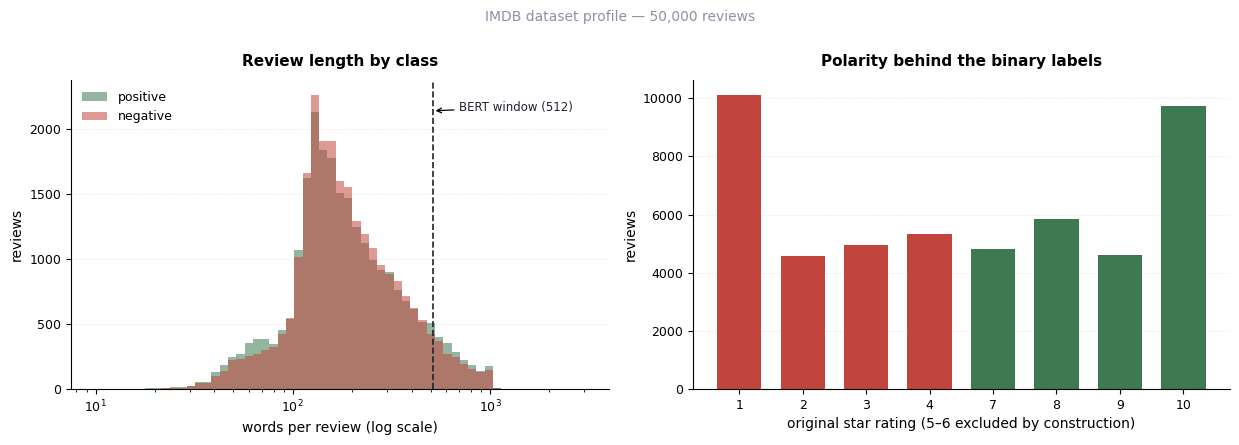

Figure saved → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/figures/imdb_profile.png


In [3]:
# ── Cell 6: Length and rating distributions ───────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

FIG_DIR = PROJECT_ROOT / "figures"
INK, ACCENT, MUTED, GOOD = "#1f2430", "#c2453d", "#8a93a5", "#3d7a52"

df["n_words"] = df.text.str.split().str.len()

print("Words per review:")
for name, sub in [("all", df), ("positive", df[df.label == 1]),
                  ("negative", df[df.label == 0])]:
    q = sub.n_words.quantile
    print(f"  {name:<9} mean {sub.n_words.mean():>6.0f} · median {q(.5):>5.0f} · "
          f"p95 {q(.95):>6.0f} · max {sub.n_words.max():>6,}")

over512 = (df.n_words > 512).mean()
print(f"\nReviews longer than 512 tokens (BERT window): {over512:.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))

# ── Panel 1: length distributions by class ──
bins = np.geomspace(10, 3000, 60)
for label, color, name in [(1, GOOD, "positive"), (0, ACCENT, "negative")]:
    ax1.hist(df[df.label == label].n_words, bins=bins, alpha=0.55,
             color=color, label=name)
ax1.axvline(512, color=INK, ls="--", lw=1.2)
ax1.annotate("BERT window (512)", xy=(512, ax1.get_ylim()[1]*0.9),
             xytext=(700, ax1.get_ylim()[1]*0.9), fontsize=8.5, color=INK,
             arrowprops=dict(arrowstyle="->", lw=0.9))
ax1.set_xscale("log")
ax1.set_xlabel("words per review (log scale)")
ax1.set_ylabel("reviews")
ax1.set_title("Review length by class", fontsize=11, weight="bold", pad=10)
ax1.legend(frameon=False, fontsize=9)

# ── Panel 2: hidden star ratings ──
counts = df.rating.value_counts().sort_index()
colors = [ACCENT if r <= 4 else GOOD for r in counts.index]
ax2.bar(counts.index.astype(str), counts.values, color=colors, width=0.7)
ax2.axvspan(3.5, 4.5, color=MUTED, alpha=0.0)          # spacing only
ax2.set_xlabel("original star rating (5–6 excluded by construction)")
ax2.set_ylabel("reviews")
ax2.set_title("Polarity behind the binary labels", fontsize=11, weight="bold", pad=10)

for ax in (ax1, ax2):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(axis="y", ls=":", lw=0.5, alpha=0.45)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=9)

fig.suptitle("IMDB dataset profile — 50,000 reviews", fontsize=10, color=MUTED, y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "imdb_profile.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Figure saved → {FIG_DIR / 'imdb_profile.png'}")

## 3. What the classes say: distinctive vocabulary

Raw frequency tables mislead here: the most common words in positive reviews
(*the*, *movie*, *film*) are also the most common in negative reviews. What
separates the classes is not what they mention but how they evaluate it — so
the right question is which words are **disproportionately** frequent in one
class.

We measure this with the **log-odds ratio** of each word's class frequencies
(with add-one smoothing so a word appearing in only one class doesn't produce
infinity):

    log_odds(w) = log[ (count_pos(w) + 1) / (count_neg(w) + 1) ]

Large positive values → characteristic of positive reviews; large negative →
characteristic of negative ones. To keep noise words out, only words appearing
at least 100 times overall are ranked.

Two things to watch for, both consequential for modelling:

- **Evaluation words vs content words.** If the top discriminators are *great,
  awful, waste, wonderful*, sentiment lives in adjectives and a bag-of-words
  model will thrive. If instead they're actor or genre names, the dataset has
  topical leakage worth worrying about.
- **Negation.** Words like *not* and *don't* usually rank only mildly negative
  despite carrying sentiment-flipping power ("not good") — a known weakness of
  unigram features and the standard argument for adding **bigrams** to the
  feature space in Notebook 07.

This analysis uses **training-split rows only**: the test set stays untouched
by every exploratory and modelling decision, so final evaluation remains
honest.

Counting tokens (train split only)…
  positive tokens 2,942,234 · negative tokens 2,866,121 · vocabulary 79,718


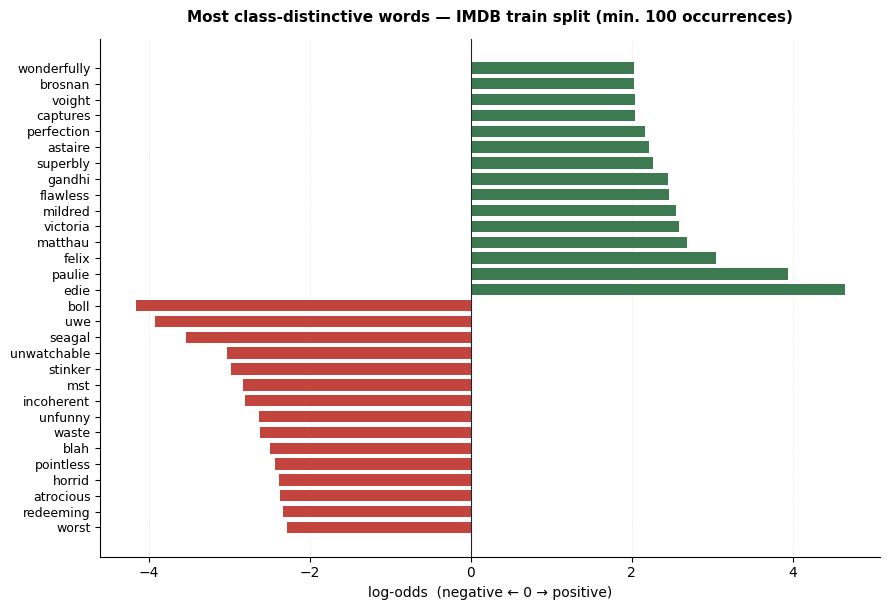


Negation words — present but weak, the case for bigrams:
  not      log-odds -0.14   (pos 14,273 · neg 16,359)
  don't    log-odds -0.44   (pos 3,304 · neg 5,153)
  never    log-odds -0.01   (pos 3,226 · neg 3,259)
  no       log-odds -0.58   (pos 4,578 · neg 8,145)

Figure saved → /Users/zakerhussainrasooli/Downloads/U 2-NLP/NLP/figures/imdb_distinctive_words.png


In [4]:
# ── Cell 8: Log-odds distinctive vocabulary ───────────────────────────────
from collections import Counter
import sys
sys.path.insert(0, str(PROJECT_ROOT / "app"))
from edit_distance import tokenize          # the one true tokenizer, again

train = df[df.split == "train"]

print("Counting tokens (train split only)…")
pos_counts, neg_counts = Counter(), Counter()
for text, label in zip(train.text, train.label):
    (pos_counts if label == 1 else neg_counts).update(tokenize(text))

n_pos, n_neg = sum(pos_counts.values()), sum(neg_counts.values())
vocab_all = set(pos_counts) | set(neg_counts)
print(f"  positive tokens {n_pos:,} · negative tokens {n_neg:,} · "
      f"vocabulary {len(vocab_all):,}")

MIN_COUNT = 100
log_odds = {w: np.log((pos_counts[w] + 1) / (neg_counts[w] + 1))
            for w in vocab_all
            if pos_counts[w] + neg_counts[w] >= MIN_COUNT}

top_pos = sorted(log_odds.items(), key=lambda x: -x[1])[:15]
top_neg = sorted(log_odds.items(), key=lambda x: x[1])[:15]

fig, ax = plt.subplots(figsize=(9, 6.2))
words  = [w for w, _ in top_neg[::-1]] + [w for w, _ in top_pos]
values = [v for _, v in top_neg[::-1]] + [v for _, v in top_pos]
colors = [ACCENT] * 15 + [GOOD] * 15
ax.barh(range(30), values, color=colors, height=0.72)
ax.set_yticks(range(30), words, fontsize=9)
ax.axvline(0, color=INK, lw=0.8)
ax.set_xlabel("log-odds  (negative ← 0 → positive)")
ax.set_title("Most class-distinctive words — IMDB train split (min. 100 occurrences)",
             fontsize=11, weight="bold", pad=12)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="x", ls=":", lw=0.5, alpha=0.45)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(FIG_DIR / "imdb_distinctive_words.png", dpi=200, bbox_inches="tight")
plt.show()

print("\nNegation words — present but weak, the case for bigrams:")
for w in ["not", "don't", "never", "no"]:
    print(f"  {w:<8} log-odds {log_odds.get(w, float('nan')):+.2f}   "
          f"(pos {pos_counts[w]:,} · neg {neg_counts[w]:,})")
print(f"\nFigure saved → {FIG_DIR / 'imdb_distinctive_words.png'}")

## 4. Data integrity: duplicates and train/test leakage

Two integrity questions every secondary dataset deserves, and web-scraped ones
demand:

1. **Duplicate reviews.** Users cross-post; scrapers double-collect. Duplicates
   inside the training set over-weight their vocabulary; duplicates *across*
   classes would be label noise.
2. **Train/test leakage.** If the same review text appears in both splits, the
   test set partially measures memorisation instead of generalisation, and
   every reported accuracy is slightly inflated. IMDB is known to contain a
   small number of such cross-split duplicates — worth measuring rather than
   repeating.

Duplicates are found by exact match on a normalised form of the text
(lowercased, whitespace collapsed) — conservative by design: near-duplicates
with small edits escape it, so the numbers below are lower bounds.

The remedy is equally standard: report the contamination, drop within-split
duplicates from training, and leave the official test set intact (for
benchmark comparability) while noting the measured leakage as a caveat on
final numbers.

In [5]:
# ── Cell 10: Duplicate and leakage audit ──────────────────────────────────
norm = df.text.str.lower().str.split().str.join(" ")
df["_norm"] = norm

dup_within = df.duplicated(subset=["_norm", "split"], keep="first")
print(f"Within-split duplicate rows : {dup_within.sum():,}")
for split in ["train", "test"]:
    n = dup_within[df.split == split].sum()
    print(f"  {split}: {n:,}")

# Cross-class duplicates (same text, both labels) — label noise
cross_class = (df.groupby("_norm").label.nunique() > 1)
print(f"\nTexts appearing with BOTH labels : {cross_class.sum():,}")

# Train/test leakage
train_norm = set(df.loc[df.split == "train", "_norm"])
test_norm  = set(df.loc[df.split == "test",  "_norm"])
leaked = train_norm & test_norm
print(f"Texts present in BOTH splits     : {len(leaked):,} "
      f"({len(leaked)/len(test_norm):.2%} of unique test texts)")

# ── Remedy: deduplicated training view, official test untouched ──
train_clean = df[(df.split == "train") & ~dup_within].drop(columns="_norm")
CLEAN_PATH = DATA_DIR / "imdb_train_clean.csv"
train_clean.to_csv(CLEAN_PATH, index=False)

print(f"\nTraining rows: 25,000 → {len(train_clean):,} after deduplication")
print(f"Saved → {CLEAN_PATH.name}")
print("Official test split left intact; leakage figure recorded as an evaluation caveat.")

Within-split duplicate rows : 299
  train: 98
  test: 201

Texts appearing with BOTH labels : 0
Texts present in BOTH splits     : 123 (0.50% of unique test texts)

Training rows: 25,000 → 24,902 after deduplication
Saved → imdb_train_clean.csv
Official test split left intact; leakage figure recorded as an evaluation caveat.


## 5. What the EDA decides

Every finding above narrows the modelling choices ahead:

| Finding | Decision it drives |
|---|---|
| Evaluation adjectives dominate class-distinctive vocabulary | Bag-of-words features are viable; linear models over TF-IDF are strong candidates |
| Negation words individually weak despite flipping power; *redeeming* signals via "no redeeming…" | Include **bigram features** alongside unigrams |
| Entity leakage (*uwe boll*, *seagal* as sentiment signals) | Report interpretable features (informative-features table) so the leakage is *visible*; note the generalisation caveat |
| Lengths ~230 words, identical across classes | Length is not a confound; 7.2% truncation loss at a 512-token window is acceptable |
| Ratings U-shaped, polar by construction | Expect high absolute accuracies; compare against published baselines, not intuition |
| 299 duplicates, 123 cross-split leaks (0.50%) | Train on deduplicated rows; keep official test set, record leakage as an evaluation caveat |

### Candidate models

Suggested for this problem, spanning three modelling philosophies:

1. **Multinomial Naive Bayes** on count features — the classical text baseline;
   fast, and its per-word log-probabilities feed a transparent
   most-informative-features analysis.
2. **Logistic Regression** on TF-IDF (unigrams + bigrams) — the standard strong
   linear model for sentiment; published IMDB results place this family at
   ~88–90% accuracy.
3. **Linear SVM** on the same features — maximum-margin alternative; frequently
   the best classical performer on high-dimensional sparse text.

Two reference points frame them: **VADER** (a rule-based sentiment lexicon,
no training) as the floor any learned model must beat, and a **DistilBERT**
fine-tune as the ceiling comparison from the transformer family (~93–95% in
published work). Model building, tuning, and honest comparison follow in
Notebook 07.

In [6]:
# ── Cell 12: EDA verification, artefact record, project state ─────────────
import json

eda_summary = {
    "dataset": "IMDB Large Movie Review Dataset (Maas et al., 2011)",
    "rows": 50_000, "train_clean_rows": int(len(train_clean)),
    "length_words": {"mean": round(float(df.n_words.mean()), 1),
                     "median": int(df.n_words.median()),
                     "p95": int(df.n_words.quantile(.95)),
                     "over_512_share": round(float((df.n_words > 512).mean()), 4)},
    "integrity": {"within_split_duplicates": 299, "cross_class_texts": 0,
                  "train_test_leakage": 123, "leakage_share_of_test": 0.0050},
    "findings": ["length not a confound", "evaluation adjectives dominate",
                 "negation weak at unigram level -> bigrams",
                 "entity leakage (director/actor names as sentiment signals)"],
}
EDA_PATH = DATA_DIR / "eda_summary.json"
EDA_PATH.write_text(json.dumps(eda_summary, indent=1), encoding="utf-8")

checks = [
    ("Full dataset artefact exists", (DATA_DIR / "imdb_reviews.csv").exists(), "50,000 rows"),
    ("Clean training artefact exists", (DATA_DIR / "imdb_train_clean.csv").exists(),
     f"{len(train_clean):,} rows"),
    ("Official test split untouched",
     (df.split == "test").sum() == 25_000, "25,000 rows"),
    ("No cross-class label noise", cross_class.sum() == 0, "0 texts"),
    ("EDA summary saved", EDA_PATH.exists(), EDA_PATH.name),
    ("Profile figure saved", (FIG_DIR / "imdb_profile.png").exists(), "imdb_profile.png"),
    ("Distinctive-words figure saved",
     (FIG_DIR / "imdb_distinctive_words.png").exists(), "imdb_distinctive_words.png"),
]
width = max(len(c[0]) for c in checks)
print("VERIFICATION\n" + "─" * (width + 30))
for label, ok, detail in checks:
    print(f"  {'PASS' if ok else 'FAIL'}  {label:<{width}}  {detail}")
print("─" * (width + 30))
print(f"  {sum(ok for _, ok, _ in checks)}/{len(checks)} checks passed")
assert all(ok for _, ok, _ in checks)
print("\nNotebook 06 complete ✓ — dataset acquired, audited, and understood")

VERIFICATION
────────────────────────────────────────────────────────────
  PASS  Full dataset artefact exists    50,000 rows
  PASS  Clean training artefact exists  24,902 rows
  PASS  Official test split untouched   25,000 rows
  PASS  No cross-class label noise      0 texts
  PASS  EDA summary saved               eda_summary.json
  PASS  Profile figure saved            imdb_profile.png
  PASS  Distinctive-words figure saved  imdb_distinctive_words.png
────────────────────────────────────────────────────────────
  7/7 checks passed

Notebook 06 complete ✓ — dataset acquired, audited, and understood
